# Compare pool metrics
Load all metrics parquets from `artifacts/` and compare MAE, RMSE, MAPE across models (baseline, prophet, lstm, xgboost, xgb_lstm_stack, chronos).

In [14]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path.cwd() / "artifacts"

files = {
    "baseline": "metrics_baseline_pool.parquet",
    "prophet": "metrics_prophet_pool.parquet",
    "lstm": "metrics_lstm_pool.parquet",
    "xgboost": "metrics_xgboost_pool.parquet",
    "xgb_lstm_stack": "metrics_xgb_lstm_stack_pool.parquet",
    "chronos": "metrics_chronos_pool.parquet",
}
dfs = []
for name, f in files.items():
    p = ARTIFACTS_DIR / f
    if p.exists():
        df = pd.read_parquet(p)
        dfs.append(df)
    else:
        print(f"Missing: {p}")

if not dfs:
    raise SystemExit("No metrics files found. Run 01–04 pool notebooks first.")
all_metrics = pd.concat(dfs, ignore_index=True)
print("Overall :")
overall = all_metrics[all_metrics["symbol"] == "overall"]
overall

Overall :


,model,symbol,MAE,RMSE,MAPE_%
2,baseline,overall,17.693195,24.615319,3.870335
5,prophet,overall,34.515905,44.771194,7.438282
8,lstm,overall,23.511871,30.038819,4.916039
11,xgboost,overall,14.931820,20.574050,3.252134
14,xgb_lstm_stack,overall,18.999560,24.788529,4.044103
17,chronos,overall,16.011076,22.469218,3.552659


In [15]:
all_metrics

,model,symbol,MAE,RMSE,MAPE_%
0,baseline,MSFT,28.319475,33.040432,6.714951
1,baseline,SPY,7.066915,7.851065,1.025719
2,baseline,overall,17.693195,24.615319,3.870335
3,prophet,MSFT,57.415211,61.097248,13.189283
4,prophet,SPY,11.616599,15.352457,1.687281
5,prophet,overall,34.515905,44.771194,7.438282
6,lstm,MSFT,33.456558,37.757686,7.857046
7,lstm,SPY,13.567184,15.558540,1.975031
8,lstm,overall,23.511871,30.038819,4.916039
9,xgboost,MSFT,24.061111,27.687833,5.659191


In [16]:
# Pivot: rows = symbol (or overall), columns = model, values = MAE / RMSE / MAPE_%
for metric in ["MAE", "RMSE", "MAPE_%"]:
    if metric not in all_metrics.columns:
        continue
    pt = all_metrics.pivot_table(index="symbol", columns="model", values=metric)
    print(f"\n--- {metric} ---")
    print(pt.to_string())
    print()


--- MAE ---
model     baseline    chronos       lstm    prophet  xgb_lstm_stack    xgboost
symbol                                                                        
MSFT     28.319475  26.474986  33.456558  57.415211       28.089248  24.061111
SPY       7.066915   5.547166  13.567184  11.616599        9.909873   5.802530
overall  17.693195  16.011076  23.511871  34.515905       18.999560  14.931820


--- RMSE ---
model     baseline    chronos       lstm    prophet  xgb_lstm_stack    xgboost
symbol                                                                        
MSFT     33.040432  30.594880  37.757686  61.097248       32.511009  27.687833
SPY       7.851065   7.194955  15.558540  15.352457       11.636870   7.107002
overall  24.615319  22.469218  30.038819  44.771194       24.788529  20.574050


--- MAPE_% ---
model    baseline   chronos      lstm    prophet  xgb_lstm_stack   xgboost
symbol                                                                    
MSFT     6.7149

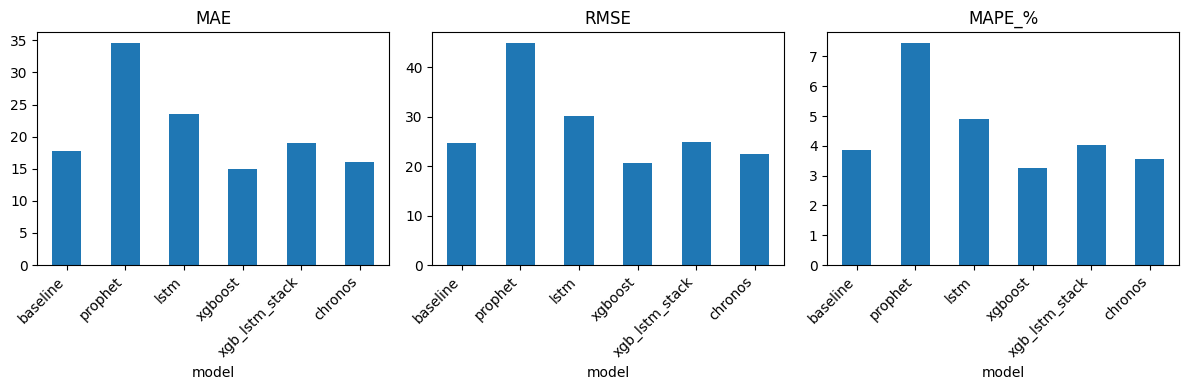

In [17]:
# Overall row only: bar comparison

if overall.empty:
    overall = all_metrics.groupby("model").agg({"MAE": "mean", "RMSE": "mean", "MAPE_%": "mean"}).reset_index()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["MAE", "RMSE", "MAPE_%"]):
    if col in overall.columns:
        overall.plot(x="model", y=col, kind="bar", ax=ax, legend=False)
        ax.set_title(col)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()